# 04 — Compute Library Features (SOAP, Magpie/matminer)

Computes SOAP descriptors (via DScribe) and Magpie/matminer atomic features for all training structures.

## Prerequisites / Input files
- `Fe-Mo/Atomsobjects/Fe-Mo-POSCAR.initial-rescaled-AtomsObjects.pkl`
- DScribe and matminer packages (public, included in `environment_public.yaml`)

## Outputs
- `Fe-Mo/Descriptors/soap_features__*.csv`
- `Fe-Mo/Descriptors/matminer_atomic_features.pkl`
- `Fe-Mo/Descriptors/DatasetFeatures.pkl`



#  Calculation of features from available libraries

In [1]:
from Tools.DatasetTools.Commoms import *
from ase import Atoms
from pymatgen.io.ase import AseAtomsAdaptor
from sklearn.metrics import r2_score

/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif', )

In [3]:
dataset = 'Fe-Mo'  # 'Cr-Co-W' # 'Fe-Mo'#
components = dataset.split('-')
system=dataset.replace('-','')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer

import Tools.DatasetTools.GeneralFeaturizer as gf

BS = pd.read_json(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.json'))
AtomsObjects = pd.read_json(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR.initial-rescaled-AtomsObjects.json')).dropna()
AtomsObjects['atoms'] = AtomsObjects['atoms'].map(Atoms.fromdict)

In [4]:
intersection = BS.index.intersection(AtomsObjects.index)

In [5]:
BS = BS.loc[intersection]
AtomsObjects = AtomsObjects.loc[intersection]

In [6]:
import ase

In [7]:
PymatgenStructures = AtomsObjects['atoms'].map(AseAtomsAdaptor.get_structure)

In [8]:

#pd.read_pickle(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR-initial-rescaled-PymatgenStructures.pkl')).dropna()
SublatticeTags = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SUBLATICETAGS_POSCAR.initial.pkl'))
SublatticeSorters = pd.read_pickle(os.path.join(dataset,'Atomsobjects', 'SORTERS_POSCAR.initial.pkl'))
SublatticeSorters.index = SublatticeSorters.index.str.strip()
SublatticeTags.index = SublatticeSorters.index.str.strip()

BS.dropna(inplace=True)

import numpy as np

# Prepare Dataset Features

In [9]:
from importlib.machinery import SourceFileLoader

In [10]:
from sklearn.preprocessing import  OneHotEncoder, LabelEncoder
encoder = LabelEncoder()

In [11]:
Features = Featurizer(BS)

In [12]:
DatasetCompositionFeatures = Features.get_fractions_by_components()

In [13]:
#DatasetFeatures = pd.concat((DatasetCompositionFeatures, DatasetMagneticFeature, StructureNameFeature), axis=1)

##  Magnetism and structure

In [14]:
structure_name_encoder = LabelEncoder()
StructureNameFeature = BS.Phase
StructureNameFeature.name='Structure'
structure_name_encoder.fit(StructureNameFeature)
DatasetStructureFeature = pd.Series(structure_name_encoder.transform(StructureNameFeature), name='Structure', index = StructureNameFeature.index)

In [15]:
MagneticFeature = Features.MagFeature

In [16]:
magnetic_encoder = LabelEncoder()
MagneticFeature.name = 'Mag'
magnetic_encoder.fit(MagneticFeature)
DatasetMagneticFeature = pd.Series(magnetic_encoder.transform(MagneticFeature), name='Mag', index = StructureNameFeature.index)

In [17]:
DatasetMagneticFeature

Fe_pv4Mo_sv20.C36-ABBBB.FM         1
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    0
Fe_pv2Mo_sv11.mu-BBABB.FM          1
Fe_pv8Mo_sv22.sigma-BBBAB.NM       0
Fe_pv2Mo_sv11.mu-BBBBA.NM          0
                                  ..
Mo_sv1.bcc.NM                      0
Mo_sv8.A15.NM                      0
Mo_sv1.fcc.NM                      0
Mo_sv6.C15.NM                      0
Fe_pv12.C14.FM                     1
Name: Mag, Length: 292, dtype: int64

In [18]:
DatasetFeatures = pd.concat([DatasetMagneticFeature, DatasetStructureFeature, DatasetCompositionFeatures, BS.num_atoms], axis = 1)

In [19]:
DatasetCompositionFeatures

,Fe_pv,Mo_sv
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.166667,0.833333
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,0.283019,0.716981
Fe_pv2Mo_sv11.mu-BBABB.FM,0.153846,0.846154
Fe_pv8Mo_sv22.sigma-BBBAB.NM,0.266667,0.733333
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.153846,0.846154
...,...,...
Mo_sv1.bcc.NM,0.000000,1.000000
Mo_sv8.A15.NM,0.000000,1.000000
Mo_sv1.fcc.NM,0.000000,1.000000
Mo_sv6.C15.NM,0.000000,1.000000


## Coordination Polyhedra feature

The first feature that we would like to have is the count of each CP in each sample. for that we construct a vector in the following way:

$$ N_{CN}^i = \#^i CP $$

Next feature we want is the composition in each CP. for this we choose to represent the elment numerically by their atomic numbers, and the CP-resolved composition becomes the average atomc numbers,

$$ Z_{CP} ^i = \dfrac{1}{n_{at}^i} \sum_{at \in CP} Z_{at} $$

In [20]:
SublatticeSorters

Fe-Mo/rawdata/Mo_sv/bulk/C15.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial                                          [7, 8, 9, 10, 11, 12]
Fe-Mo/rawdata/Mo_sv/bulk/mu.FM/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial               [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Fe-Mo/rawdata/Mo_sv/bulk/C36/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial                 [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...
Fe-Mo/rawdata/Mo_sv/bulk/R/relax/xc=PBE-PAW.E=450.dk=0.020/POSCAR.initial                   [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...
Fe-Mo/rawdata/Mo_sv/bulk/C14.FM/relax/xc=PBE-PAW.E=400.dk=0.020/POSCAR.initial                  [15, 16, 17, 18, 7, 8, 9, 10, 11, 12, 13, 14]
                                                                                                                  ...                        
Fe-Mo/rawdata/Fe_pv/bulk/bcc-cubic.FM/relax/xc=PBE-PAW.E=440.dk=0.020/POSCAR.initial                                                       []
Fe-Mo/

In [21]:
gf = SourceFileLoader('gf','Tools/DatasetTools/GeneralFeaturizer.py').load_module()

In [22]:
SortingFeatures = gf.sorting_feature(AtomsObjects, SublatticeSorters, SublatticeTags)

In [23]:
SortingFeatures.sorters = gf.correct_sortings_fromphases(AtomsObjects.loc[BS.index], BS.Phase, SortingFeatures.sorters[BS.index])
SortingFeatures.sublatticetags = gf.correct_occupation_fromphases(BS.Phase, SortingFeatures.sublatticetags, AtomsObjects.atoms)
sampleinspecial = BS.Phase.map(lambda p: p in gf.specialphases)
empty = SortingFeatures.sublatticetags.map(lambda sublat: '' in sublat)
SortingFeatures.sublatticetags[empty] = ['A']
wrong = SortingFeatures.sublatticetags.map(lambda sublat: 'A' not in sublat) 
fixable = SortingFeatures.sublatticetags.loc[wrong].map(type) == np.ndarray #.map(np.unique)
CNList = gf.get_sitecn(BS.Phase, AtomsObjects.atoms, SortingFeatures.sorters)

100%|██████████| 292/292 [00:00<00:00, 175740.68it/s]


## Position Features

In [24]:
elements = np.unique(BS.filter(regex='^atom_').values.ravel())
ABOCC = pd.concat([BS.filter(regex='atom_'), Features.occupation], axis = 1)
ABOCC.rename(columns={ABOCC.columns[-1]: 'index'}, inplace=True)

In [25]:
Positions = {}
for index, item in ABOCC.iterrows():
    if item['index'] == '':
        thisposition = {index: [item[f'atom_A']]*len(np.unique(gf.cn_dict[BS.Phase[index]]))}
    else:
        thisposition = {index: [item[f'atom_{occ}'] for occ in item['index'] ]}
    Positions.update(thisposition)
Positions = pd.DataFrame.from_dict(Positions, orient='index')
Positions[Positions.isnull()] = 0
for i, element in enumerate(elements):
    Positions[Positions==element] = i
Positions.columns = [f'Pos_{col+1}' for col in Positions.columns]
#Positions[Positions.Pos_1.map(type) == str] = np.nan

## Averages over Coordination polyhedra

### Number of each CP in each structure

In [26]:
CN = gf.featurize_series(CNList, CNList, normalization='NCP', return0 = False)
newcolumns = ['N'+col for col in CN.columns]
CN.columns = newcolumns

### Composition and volume of the CP

In [27]:
from mendeleev import element

In [28]:
AtomicNumbers=AtomsObjects.atoms.map(lambda a: a.numbers)
AtomicNumbers.name = 'AtomicNumbers'
symbols = dataset.split('-')
volums = {symb: element(symb).atomic_volume for symb in symbols}

In [29]:
AtomicVolumes = AtomsObjects.atoms.map(lambda a: np.array([volums[at] for at in a.get_chemical_symbols()]))

In [30]:
CNList

Fe_pv4Mo_sv20.C36-ABBBB.FM         [16, 16, 16, 16, 16, 16, 16, 16, 12, 12, 12, 1...
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 1...
Fe_pv2Mo_sv11.mu-BBABB.FM          [15, 15, 12, 12, 12, 12, 12, 12, 12, 16, 16, 1...
Fe_pv8Mo_sv22.sigma-BBBAB.NM       [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 15, 1...
Fe_pv2Mo_sv11.mu-BBBBA.NM          [14, 14, 12, 12, 12, 12, 12, 12, 12, 15, 15, 1...
                                                         ...                        
Mo_sv1.bcc.NM                                                                   [14]
Mo_sv8.A15.NM                                       [14, 14, 14, 14, 14, 14, 12, 12]
Mo_sv1.fcc.NM                                                                   [12]
Mo_sv6.C15.NM                                               [16, 16, 12, 12, 12, 12]
Fe_pv12.C14.FM                      [12, 12, 12, 12, 12, 12, 12, 12, 16, 16, 16, 16]
Length: 292, dtype: object

In [31]:
CPVol = gf.featurize_series(AtomicVolumes.loc[CNList.index], CNList, return0=False, normalization='NCP')

In [32]:
newcolumns = ['V'+col for col in CPVol.columns]
CPVol.columns =  newcolumns

In [33]:
CPComp = gf.featurize_series(AtomicNumbers.loc[CNList.index], CNList, return0=False, normalization='NCP')
newcolumns = ['Z'+col for col in CPComp.columns]
CPComp.columns = newcolumns

## Compile all the descriptors

In [34]:
DatasetFeatures = pd.concat([DatasetStructureFeature, DatasetMagneticFeature, DatasetCompositionFeatures, CN, CPVol, CPComp, BS.num_atoms, Positions], axis=1)
datasetfeatureslocation = os.path.join(dataset, 'Descriptors','DatasetFeatures.pkl')
CNListlocation = os.path.join(dataset, 'Descriptors', 'CNList.pkl')
DatasetFeatures.to_pickle(datasetfeatureslocation)
CNList.to_pickle(CNListlocation)

In [35]:
DatasetFeatures.columns

Index(['Structure', 'Mag', 'Fe_pv', 'Mo_sv', 'N_CN12', 'N_CN13', 'N_CN14',
       'N_CN15', 'N_CN16', 'V_CN12', 'V_CN13', 'V_CN14', 'V_CN15', 'V_CN16',
       'Z_CN12', 'Z_CN13', 'Z_CN14', 'Z_CN15', 'Z_CN16', 'num_atoms', 'Pos_1',
       'Pos_2', 'Pos_3', 'Pos_4', 'Pos_5', 'Pos_6', 'Pos_7', 'Pos_8', 'Pos_9',
       'Pos_10', 'Pos_11'],
      dtype='object')

# Matminer Features 

In [36]:
from Tools.DatasetTools.GetPymatgenFeatures import get_chemical_formula, load_features#*
from matminer.featurizers.conversions import StrToComposition

In [37]:
descriptorslocation = os.path.join(dataset, 'Descriptors')
mmflatomic = os.path.join(descriptorslocation, 'matminer_atomic_features.pkl')
mmfdensity = os.path.join (descriptorslocation, 'matminer_density_features.pkl')
mmfcomposition =  os.path.join (descriptorslocation,'matminer_composition_features.pkl')
mmfstructure =  os.path.join (descriptorslocation,'matminer_structure_features.pkl')
mmsoapfeatures = os.path.join(descriptorslocation, 'matminer_soap_features.pkl')


BS['chemical_formula'] = get_chemical_formula(BS)

In [38]:
if 'composition' not in BS.columns: 
    BS['composition'] = StrToComposition().featurize_dataframe(BS, "chemical_formula")['composition']

StrToComposition: 100%|██████████| 292/292 [00:00<00:00, 3080.34it/s]


In [39]:
if 'atoms_objects' not in BS.columns:
    BS['atoms_objects'] = PymatgenStructures

In [40]:
AtomicFeaturesMagpie = load_features(mmflatomic, BS, which='atomic')
DensitiFeatures= load_features(mmfdensity, BS, which='density')
CompositionFeatures = load_features(mmfcomposition, BS, which='composition')
# SOAP doesnt work from matminer
# StructureFeatures = load_features(mmfstructure, BS, which='structure')

In [41]:
AtomicFeaturesMagpie.columns = AtomicFeaturesMagpie.columns.str.replace('MagpieData ','')
AtomicFeaturesMagpie.dropna(axis=1, inplace = True)
AtomicFeaturesMagpie.describe()

,minimum Number,maximum Number,range Number,mean Number,avg_dev Number,mode Number,minimum MendeleevNumber,maximum MendeleevNumber,range MendeleevNumber,mean MendeleevNumber,...,range GSmagmom,mean GSmagmom,avg_dev GSmagmom,mode GSmagmom,minimum SpaceGroupNumber,maximum SpaceGroupNumber,range SpaceGroupNumber,mean SpaceGroupNumber,avg_dev SpaceGroupNumber,mode SpaceGroupNumber
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,...,292.000000,292.000000,292.000000,292.000000,292.0,292.0,292.0,292.0,292.0,292.0
mean,27.205479,40.739726,13.534247,33.967062,5.269563,33.506849,50.393836,54.623288,4.229452,52.510293,...,1.785389,1.059676,0.695142,1.026418,229.0,229.0,0.0,229.0,0.0,229.0
std,4.230340,4.317398,5.786778,4.681610,2.806171,7.998493,1.349187,1.321981,1.808368,1.463003,...,0.763371,0.617581,0.370180,1.056746,0.0,0.0,0.0,0.0,0.0,0.0
min,26.000000,26.000000,0.000000,26.000000,0.000000,26.000000,50.000000,50.000000,0.000000,50.000000,...,0.000000,0.000000,0.000000,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
25%,26.000000,42.000000,16.000000,30.266667,4.101104,26.000000,50.000000,55.000000,5.000000,51.333333,...,2.110663,0.562843,0.541003,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
50%,26.000000,42.000000,16.000000,34.000000,6.257778,26.000000,50.000000,55.000000,5.000000,52.500000,...,2.110663,1.055331,0.825504,0.000000,229.0,229.0,0.0,229.0,0.0,229.0
75%,26.000000,42.000000,16.000000,37.733333,7.680000,42.000000,50.000000,55.000000,5.000000,53.666667,...,2.110663,1.547819,1.013118,2.110663,229.0,229.0,0.0,229.0,0.0,229.0
max,42.000000,42.000000,16.000000,42.000000,8.000000,42.000000,55.000000,55.000000,5.000000,55.000000,...,2.110663,2.110663,1.055331,2.110663,229.0,229.0,0.0,229.0,0.0,229.0


In [42]:
DensitiFeatures.dropna(axis=1, inplace=True)
if DensitiFeatures.shape[1] > 0:
    DensitiFeatures.describe()

In [43]:
CompositionFeatures.dropna(axis=1, inplace=True)
CompositionFeatures.describe()

,HOMO_energy,LUMO_energy,gap_AO,band center,max ionic char,avg ionic char,0-norm,2-norm,3-norm,5-norm,7-norm,10-norm
count,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000,292.000000
mean,-0.194195,-0.190286,0.003909,3.975919,0.022719,0.004423,1.845890,0.812482,0.775176,0.755694,0.750322,0.747481
std,0.058855,0.056289,0.017809,0.033361,0.009714,0.002355,0.361674,0.102766,0.129532,0.146966,0.152717,0.156080
min,-0.295049,-0.295049,0.000000,3.918947,0.000000,0.000000,1.000000,0.707107,0.629961,0.574349,0.552045,0.535887
25%,-0.197978,-0.197978,0.000000,3.949031,0.026858,0.003442,2.000000,0.721110,0.654213,0.615030,0.604895,0.601032
50%,-0.153347,-0.153347,0.000000,3.975545,0.026858,0.005252,2.000000,0.780313,0.744904,0.734264,0.733421,0.733336
75%,-0.153347,-0.153347,0.000000,4.002236,0.026858,0.006446,2.000000,0.862369,0.850644,0.849087,0.849057,0.849057
max,-0.153347,-0.153347,0.097071,4.032960,0.026858,0.006714,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# SOAPFeatures

In [44]:
from dscribe.descriptors import SOAP
from mendeleev import element
import ase
from sklearn.feature_selection import VarianceThreshold

In [45]:
atomsobjectlocation = os.path.join(dataset, 'Atomsobjects')
atomsobjectfile = os.path.join(atomsobjectlocation,f'{dataset}-POSCAR.initial-rescaled-AtomsObjects.json')

In [46]:
from ase import Atoms
AtomsObjects = pd.read_json(atomsobjectfile).dropna().loc[intersection]
AtomsObjects['atoms'] = AtomsObjects['atoms'].map(Atoms.fromdict)

## Canonical and specific

In [47]:
def reset_symbols(a: ase.atoms.Atoms, newsym : str = 'W'):
    newa = a.copy()
    natoms = newa.get_global_number_of_atoms()
    newsymbols = [newsym]*natoms
    newa.set_chemical_symbols(newsymbols)
    return newa

In [48]:
soapcases = ['canonicalFe','canonicalW','specific']

In [113]:
SOAPFEATURES = {}
EXPANDED_SOAP = {}
AVE_SOAP = {}
variances = {}
SEL_SOAP = {}
FINAL_SOAP = {}
soap_params = dict(
    r_cut = 4,
    n_max = 5,
    l_max = 4, # f
    sigma = 0.1,
    rbf = 'gto',
    periodic = True,
    compression = dict(mode='off')
)
params_str = '__'.join([f'{key}_{val}' for key, val in soap_params.items()])
soap_features_file={}

In [114]:
AtomsObjects = AtomsObjects.loc[BS.index]

In [115]:
for soapcase in soapcases:
    print(soapcase)
    soap_features_file.update({soapcase: os.path.join(descriptorslocation, f'soap_features__{soapcase}__{params_str}.csv')})
    if 'canonicalFe' in soapcase:
        species=[26]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'Fe'))
    elif 'canonicalW' in soapcase:
        species=[74]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: reset_symbols(a, 'W'))
    elif 'specific' in soapcase:
        species = [element(s).atomic_number for s in dataset.split('-')]
        thisatomsobjects = AtomsObjects['atoms'].map(lambda a: copy.deepcopy(a))
    SOAPER = SOAP(species=species, **soap_params)
    SOAPFEATURES.update({soapcase: thisatomsobjects.map(SOAPER.create)}) #,pd.DataFrame(data= columns=['SOAP'])
    EXPANDED_SOAP.update({soapcase: gf.array_expansions(SOAPFEATURES[soapcase].to_frame(name='SOAP'), ['SOAP'])})
    AVE_SOAP.update({soapcase: gf.featurize_dataframe(EXPANDED_SOAP[soapcase], CNList)})
    AVE_SOAP[soapcase].to_csv(soap_features_file[soapcase])
#    variances.update({soapcase: {name: col.var() for name, col in AVE_SOAP[soapcase].iteritems()}})
    selector = VarianceThreshold(threshold=1e-9)
    SEL_SOAP.update({soapcase: selector.fit_transform(AVE_SOAP[soapcase])})
    FINAL_SOAP.update({soapcase: pd.DataFrame(data=SEL_SOAP[soapcase], columns = selector.get_feature_names_out(), index=AVE_SOAP[soapcase].index)})
    FINAL_SOAP[soapcase].to_csv(soap_features_file[soapcase])

canonicalFe


100%|██████████| 75/75 [00:00<00:00, 168.99it/s]


canonicalW


100%|██████████| 75/75 [00:00<00:00, 127.82it/s]


specific


100%|██████████| 275/275 [00:01<00:00, 170.14it/s]


In [116]:
AVE_SOAP['specific'].shape

(292, 1650)

In [117]:
AVE_SOAP['specific'].columns

Index(['SOAP_0_0', 'SOAP_0_CN12', 'SOAP_0_CN13', 'SOAP_0_CN14', 'SOAP_0_CN15',
       'SOAP_0_CN16', 'SOAP_1_0', 'SOAP_1_CN12', 'SOAP_1_CN13', 'SOAP_1_CN14',
       ...
       'SOAP_273_CN13', 'SOAP_273_CN14', 'SOAP_273_CN15', 'SOAP_273_CN16',
       'SOAP_274_0', 'SOAP_274_CN12', 'SOAP_274_CN13', 'SOAP_274_CN14',
       'SOAP_274_CN15', 'SOAP_274_CN16'],
      dtype='object', length=1650)

In [118]:
AVE_SOAP['specific'].shape

(292, 1650)

In [119]:
variances = AVE_SOAP['specific'].var()
#screenvariances = FINAL_SOAP['specific'].var()

In [120]:
maxvar = variances.max()
minvar = variances.min()
bins = np.logspace(np.log10(minvar), np.log10(maxvar), num=100)

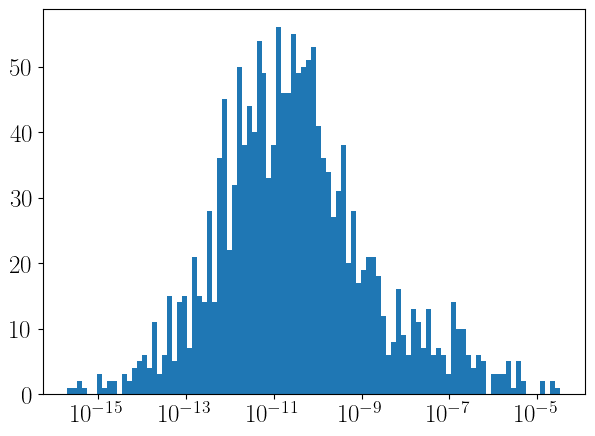

In [121]:
figm, ax = plt.subplots()
hist = ax.hist(variances, bins=bins)
#hist = ax.hist(screenvariances, bins=bins)
ax.set_xscale('log')


## SOAP on relaxed atoms

In [122]:
AtomsObjectsRLX = pd.read_json(os.path.join(dataset, 'Atomsobjects', f'{dataset}-POSCAR.relaxed-all-noscaled-AtomsObjects.json')).dropna()
AtomsObjectsRLX['atoms'] = AtomsObjectsRLX['atoms'].map(Atoms.fromdict)

In [123]:
AtomsObjectsRLX = AtomsObjectsRLX.loc[intersection]

In [124]:
SOAPER = SOAP(species=species, **soap_params)

In [125]:
SOAPFEATURES_RLX = AtomsObjectsRLX['atoms'].map(SOAPER.create)
SOAPFEATURES_RLX.name = 'SOAP'

In [126]:
SOAPFEATURES_RLX

Fe_pv4Mo_sv20.C36-ABBBB.FM         [[0.019616819982164448, 0.0006582536792664118,...
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    [[0.019623236760920804, 0.0006471666667773442,...
Fe_pv2Mo_sv11.mu-BBABB.FM          [[0.01969824566050658, 0.0005062026429642476, ...
Fe_pv8Mo_sv22.sigma-BBBAB.NM       [[0.019630487297815514, 0.0006232874599752808,...
Fe_pv2Mo_sv11.mu-BBBBA.NM          [[0.019548991752305123, 0.0007653225388151172,...
                                                         ...                        
Mo_sv1.bcc.NM                      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Mo_sv8.A15.NM                      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Mo_sv1.fcc.NM                      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Mo_sv6.C15.NM                      [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
Fe_pv12.C14.FM                     [[0.019679272391047924, 0.00041991881411157506...
Name: SOAP, Length: 292, dtype: object

In [127]:
EXPANDED_SOAP_RLX = gf.array_expansions(SOAPFEATURES_RLX.to_frame(), [ 'SOAP' ])

In [128]:
AVE_SOAP_RLX = gf.featurize_dataframe(EXPANDED_SOAP_RLX, CNList)

100%|██████████| 275/275 [00:01<00:00, 180.06it/s]


In [129]:
AVE_SOAP_RLX

,SOAP_0_0,SOAP_0_CN12,SOAP_0_CN13,SOAP_0_CN14,SOAP_0_CN15,SOAP_0_CN16,SOAP_1_0,SOAP_1_CN12,SOAP_1_CN13,SOAP_1_CN14,...,SOAP_273_CN13,SOAP_273_CN14,SOAP_273_CN15,SOAP_273_CN16,SOAP_274_0,SOAP_274_CN12,SOAP_274_CN13,SOAP_274_CN14,SOAP_274_CN15,SOAP_274_CN16
Fe_pv4Mo_sv20.C36-ABBBB.FM,0.003270,6.252955e-08,0.0,0.000000e+00,0.000000e+00,3.269486e-03,0.000109,-2.342157e-07,0.0,0.000000e+00,...,0.0,0.000000,0.000000e+00,-4.109991e-06,0.000073,0.000070,0.0,0.000000e+00,0.000000e+00,2.877047e-06
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,0.005542,5.542029e-03,0.0,2.403289e-08,2.359995e-08,5.955191e-08,0.000194,1.944591e-04,0.0,-9.980833e-08,...,0.0,-0.000025,-6.014442e-06,-5.803822e-06,0.000076,0.000045,0.0,2.115528e-05,4.877687e-06,4.496289e-06
Fe_pv2Mo_sv11.mu-BBABB.FM,0.003031,1.702233e-08,0.0,3.409451e-08,3.030499e-03,0.000000e+00,0.000078,-7.005080e-08,0.0,-1.240936e-07,...,0.0,-0.000017,-2.448233e-06,-2.198809e-06,0.000051,0.000031,0.0,1.598811e-05,1.901078e-06,1.895190e-06
Fe_pv8Mo_sv22.sigma-BBBAB.NM,0.005235,5.234799e-03,0.0,7.505514e-08,2.672431e-08,0.000000e+00,0.000166,1.661993e-04,0.0,-3.119734e-07,...,0.0,-0.000077,-7.826514e-06,0.000000e+00,0.000110,0.000025,0.0,7.844119e-05,6.779238e-06,0.000000e+00
Fe_pv2Mo_sv11.mu-BBBBA.NM,0.003008,2.440474e-08,0.0,3.007537e-03,4.717816e-08,1.495281e-09,0.000117,-9.462758e-08,0.0,1.177419e-04,...,0.0,-0.000001,-6.024104e-07,-8.872026e-08,0.000058,0.000057,0.0,8.752724e-07,4.026633e-07,7.374612e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mo_sv1.bcc.NM,0.000000,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.000000e+00,...,0.0,-0.000143,0.000000e+00,0.000000e+00,0.000123,0.000000,0.0,1.231495e-04,0.000000e+00,0.000000e+00
Mo_sv8.A15.NM,0.000000,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.000000e+00,...,0.0,-0.000058,0.000000e+00,0.000000e+00,0.000080,0.000024,0.0,5.637891e-05,0.000000e+00,0.000000e+00
Mo_sv1.fcc.NM,0.000000,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.000000e+00,...,0.0,0.000000,0.000000e+00,0.000000e+00,0.000052,0.000052,0.0,0.000000e+00,0.000000e+00,0.000000e+00
Mo_sv6.C15.NM,0.000000,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0,0.000000e+00,...,0.0,0.000000,0.000000e+00,-2.052631e-05,0.000044,0.000022,0.0,0.000000e+00,0.000000e+00,2.171991e-05


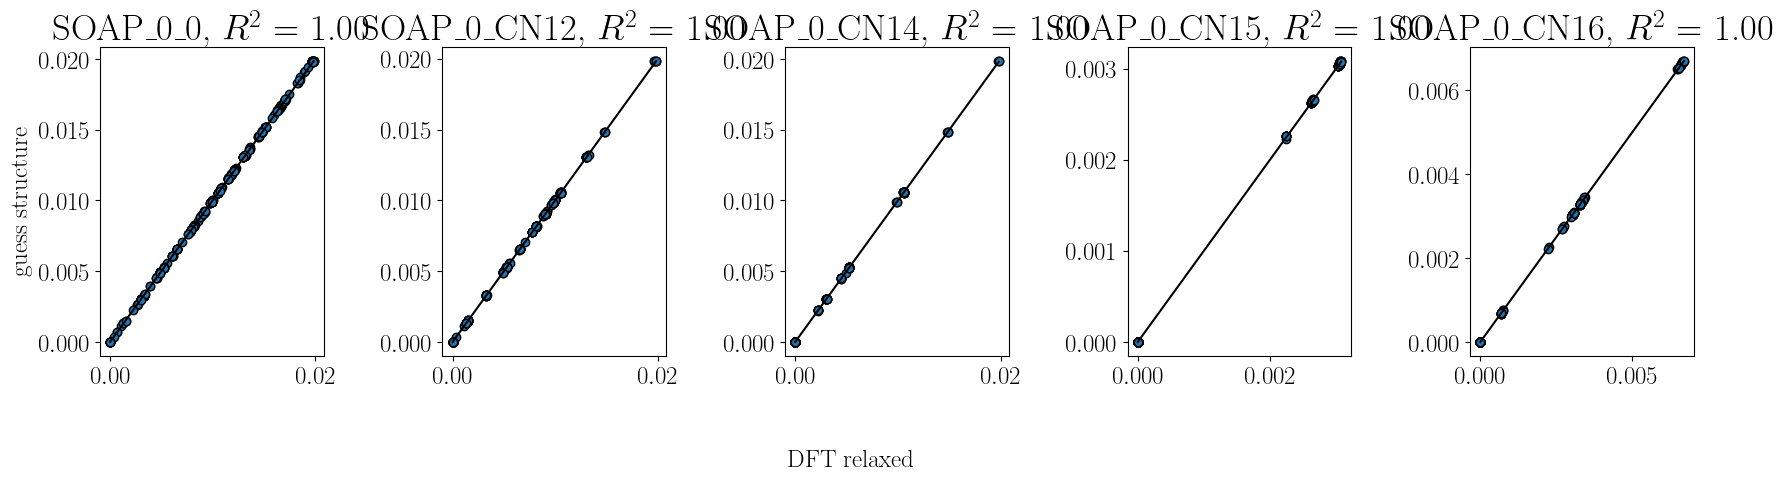

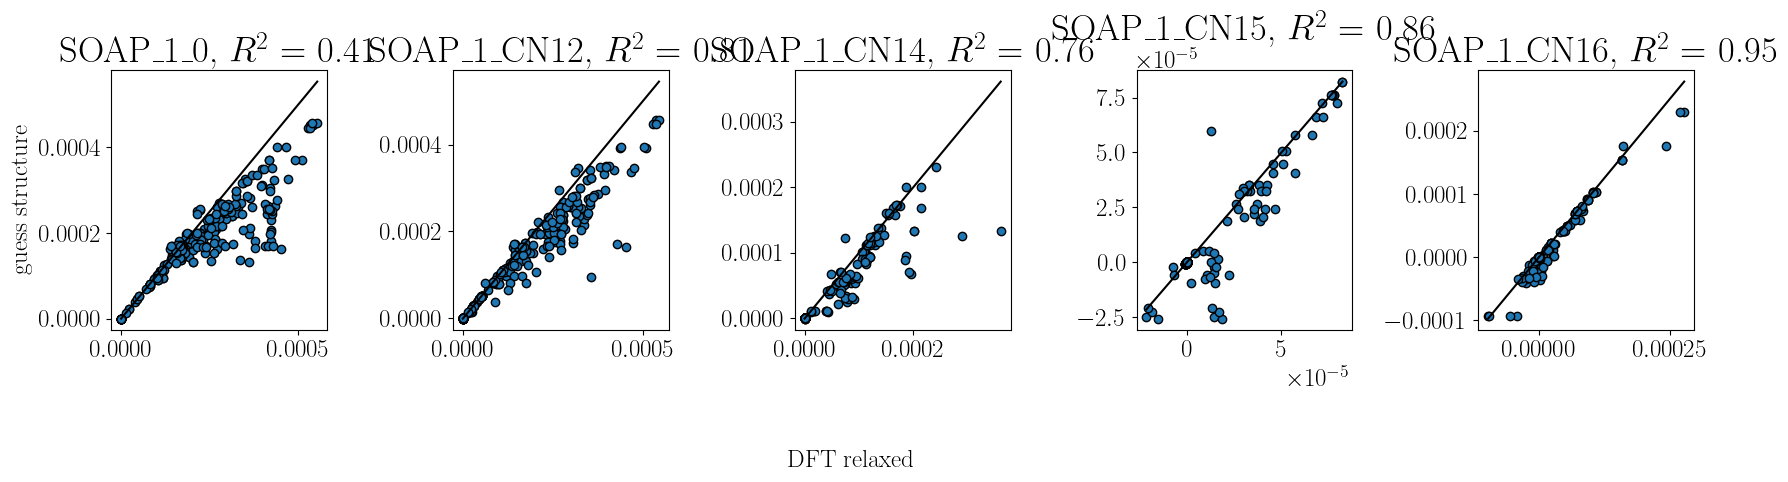

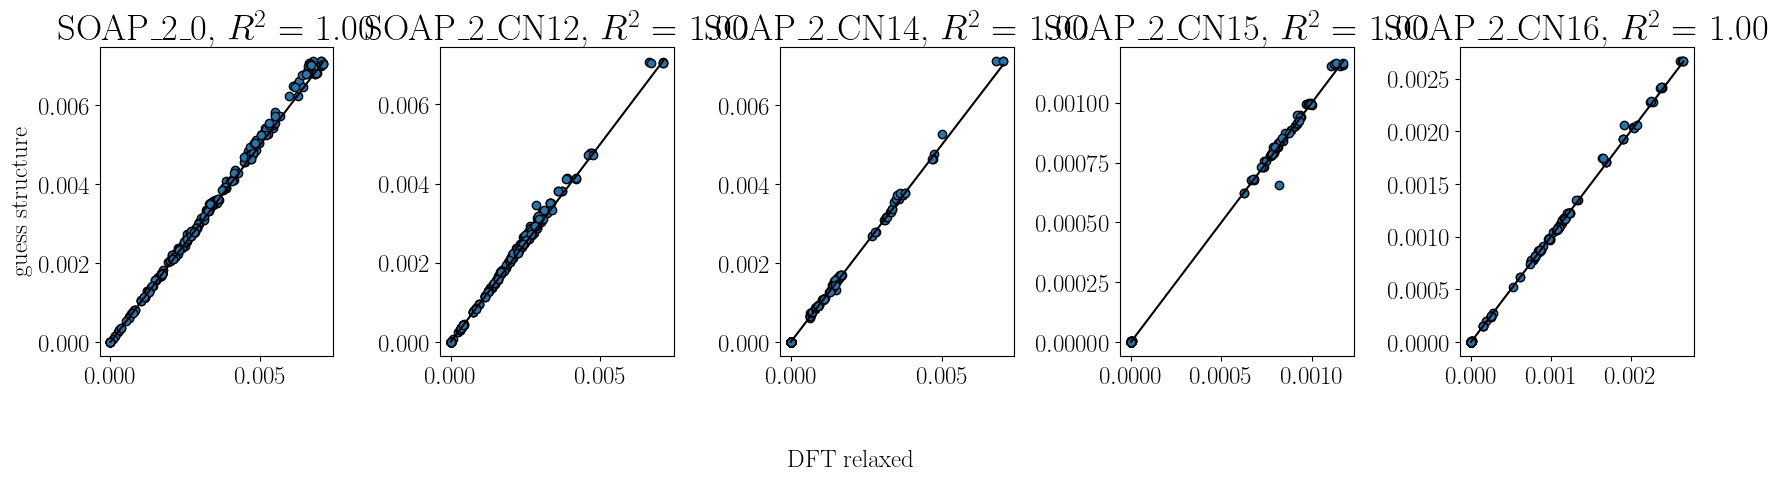

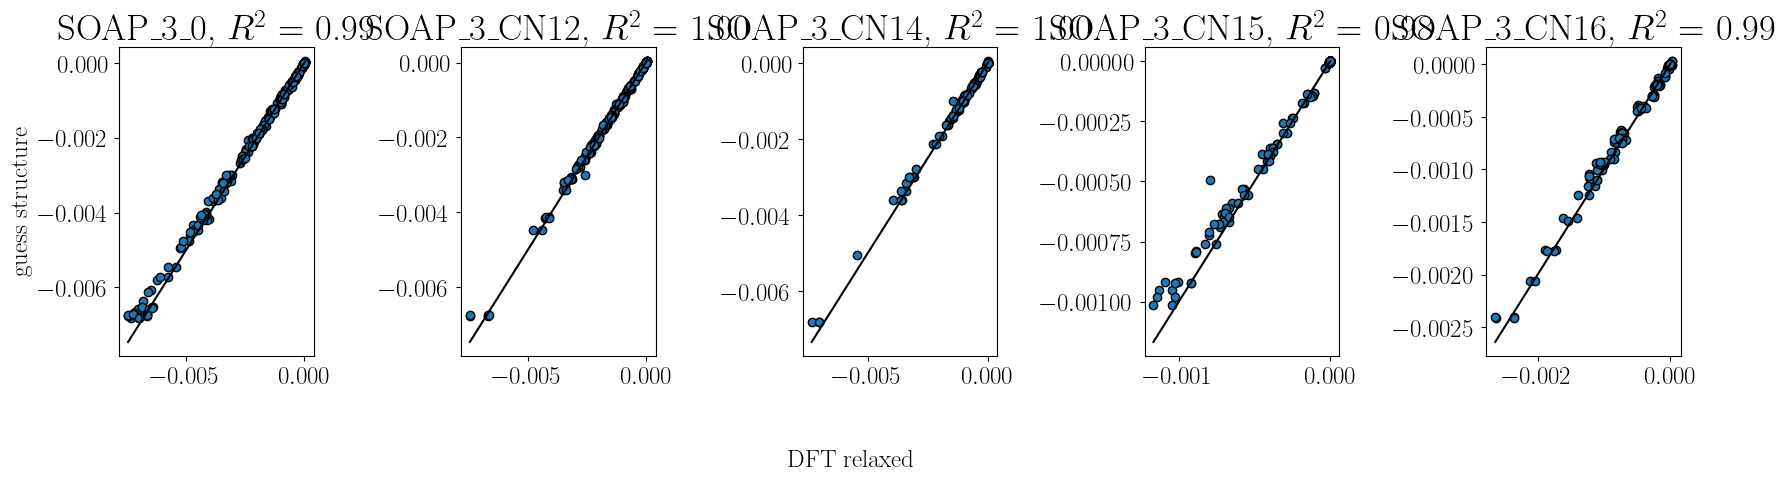

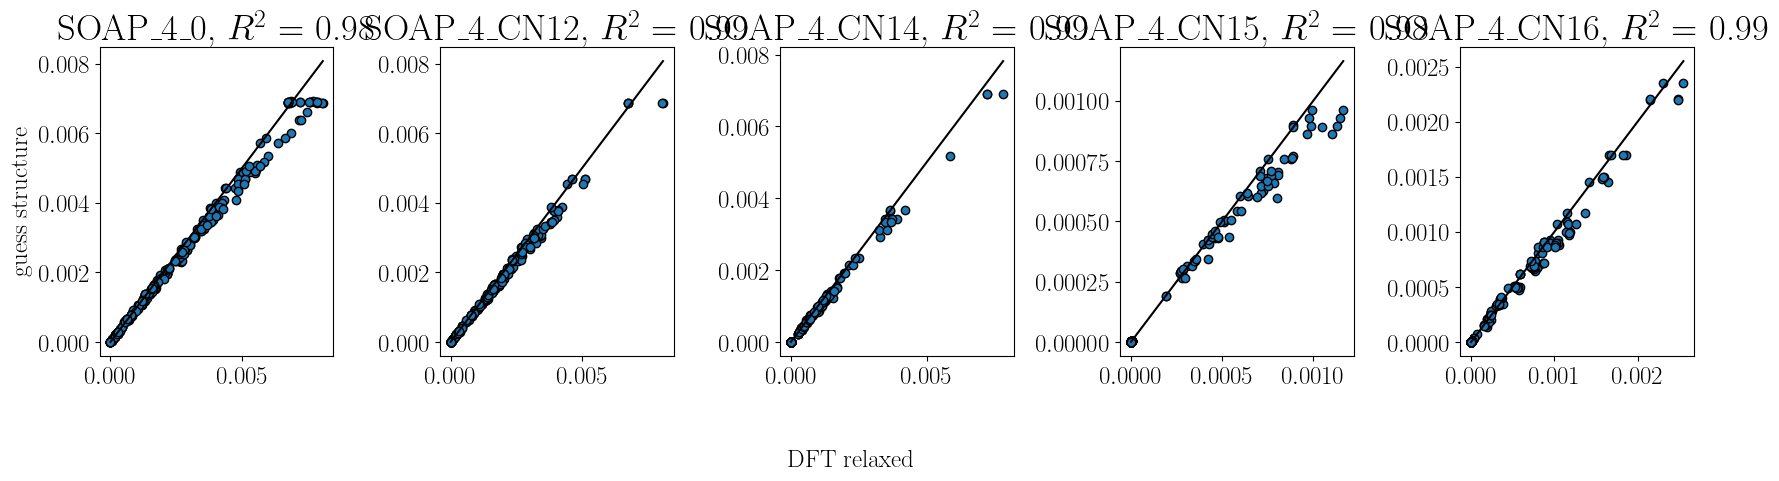

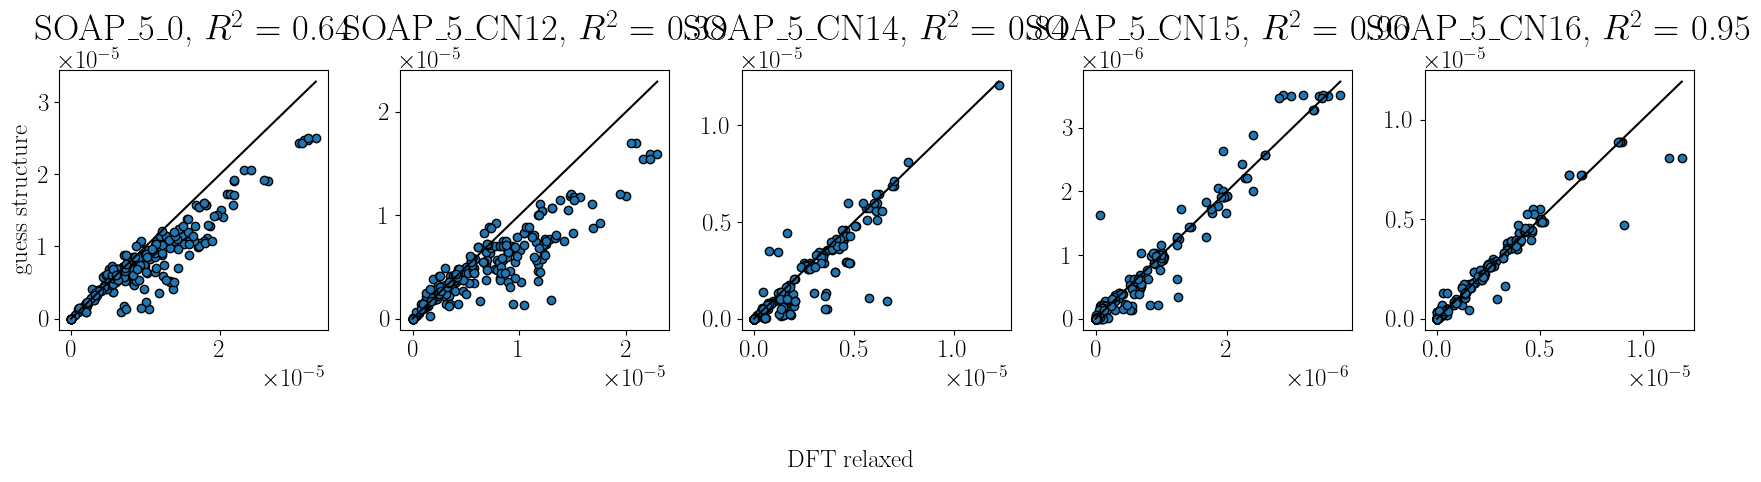

In [130]:
for i in range(6):
    fw, fh = plt.rcParams['figure.figsize']
    fig,axs = plt.subplots(1,5, figsize=(fw*5/2, fh))
    for CN, ax in zip(['0','CN12', 'CN14', 'CN15', 'CN16'], axs):
        feature = f'SOAP_{i}_{CN}'
        x = AVE_SOAP_RLX[feature]
        y = AVE_SOAP['specific'][feature]
    #    reg = np.poly1d(np.polyfit(x, y, 1))
    #    ytilde = reg(x)
        r2 = r2_score(y, x)
        ax.scatter(x, y , ec='k')
        proj_0_range = [x.min(), x.max()] 
        ax.plot(proj_0_range, proj_0_range, 'k')
        ax.set_title(feature+f', $R^2$ = {r2:.2f}')
    axs[0].set_ylabel('guess structure')
    fig.supxlabel('DFT relaxed', fontsize=18)
    fig.tight_layout()

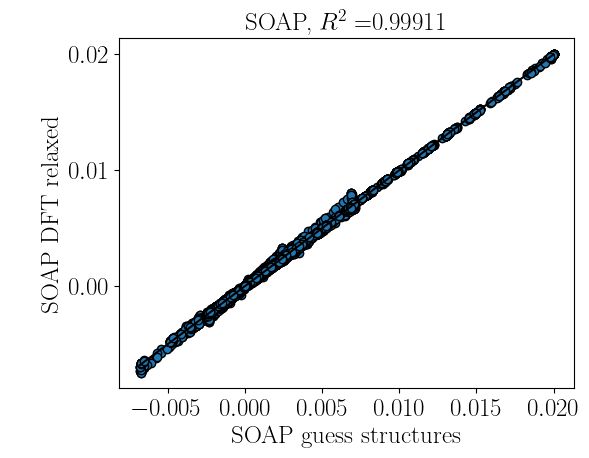

In [131]:
X=    np.ravel(AVE_SOAP['specific'])
Y=    np.ravel(AVE_SOAP_RLX)
fig = plt.figure()
ax = fig.add_subplot([0.25, 0.2, 0.65, 0.7])
ax.scatter(X,Y, ec='k')
#plt.yscale('log')
#plt.xscale('log')
therange = [X.min(), X.max()]
r2 = r2_score(X,Y)
plt.ylabel('SOAP DFT relaxed')
plt.xlabel('SOAP guess structures')
plt.plot(therange,therange, '-k')
plt.title(f'SOAP, $R^2 = ${r2:.5f}', fontsize=18)
plt.savefig('Fe-Mo/graphs/Figure_Fe-Mo_SOAP_rlx-vs-ini.png', dpi=300)


# Characterization of Features 

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

##  Correlations

In [69]:
plt.rc('font',size=22)

In [70]:
target_case = 'EF_nmhcp'

In [71]:
BS[target_case]

Fe_pv4Mo_sv20.C36-ABBBB.FM         0.478663
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM    0.133919
Fe_pv2Mo_sv11.mu-BBABB.FM          0.403272
Fe_pv8Mo_sv22.sigma-BBBAB.NM       0.058290
Fe_pv2Mo_sv11.mu-BBBBA.NM          0.363607
                                     ...   
Mo_sv1.bcc.NM                      0.000000
Mo_sv8.A15.NM                      0.095306
Mo_sv1.fcc.NM                      0.421784
Mo_sv6.C15.NM                      0.367463
Fe_pv12.C14.FM                     0.149237
Name: EF_nmhcp, Length: 292, dtype: float64

In [72]:
FeatureGroups = {'density features': DensitiFeatures, 'atomic features': AtomicFeaturesMagpie, 'composition features': CompositionFeatures, 'Dataset Features': DatasetFeatures}


In [73]:
TargetCorrelations = {}
y = pd.to_numeric(BS[target_case], errors='coerce')

for groupname, GroupFeatures in FeatureGroups.items():
    X_num = GroupFeatures.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
    corr = X_num.corrwith(y).dropna().sort_values(ascending=False)
    TargetCorrelations[groupname] = corr

In [74]:
len(TargetCorrelations)

4

[None]

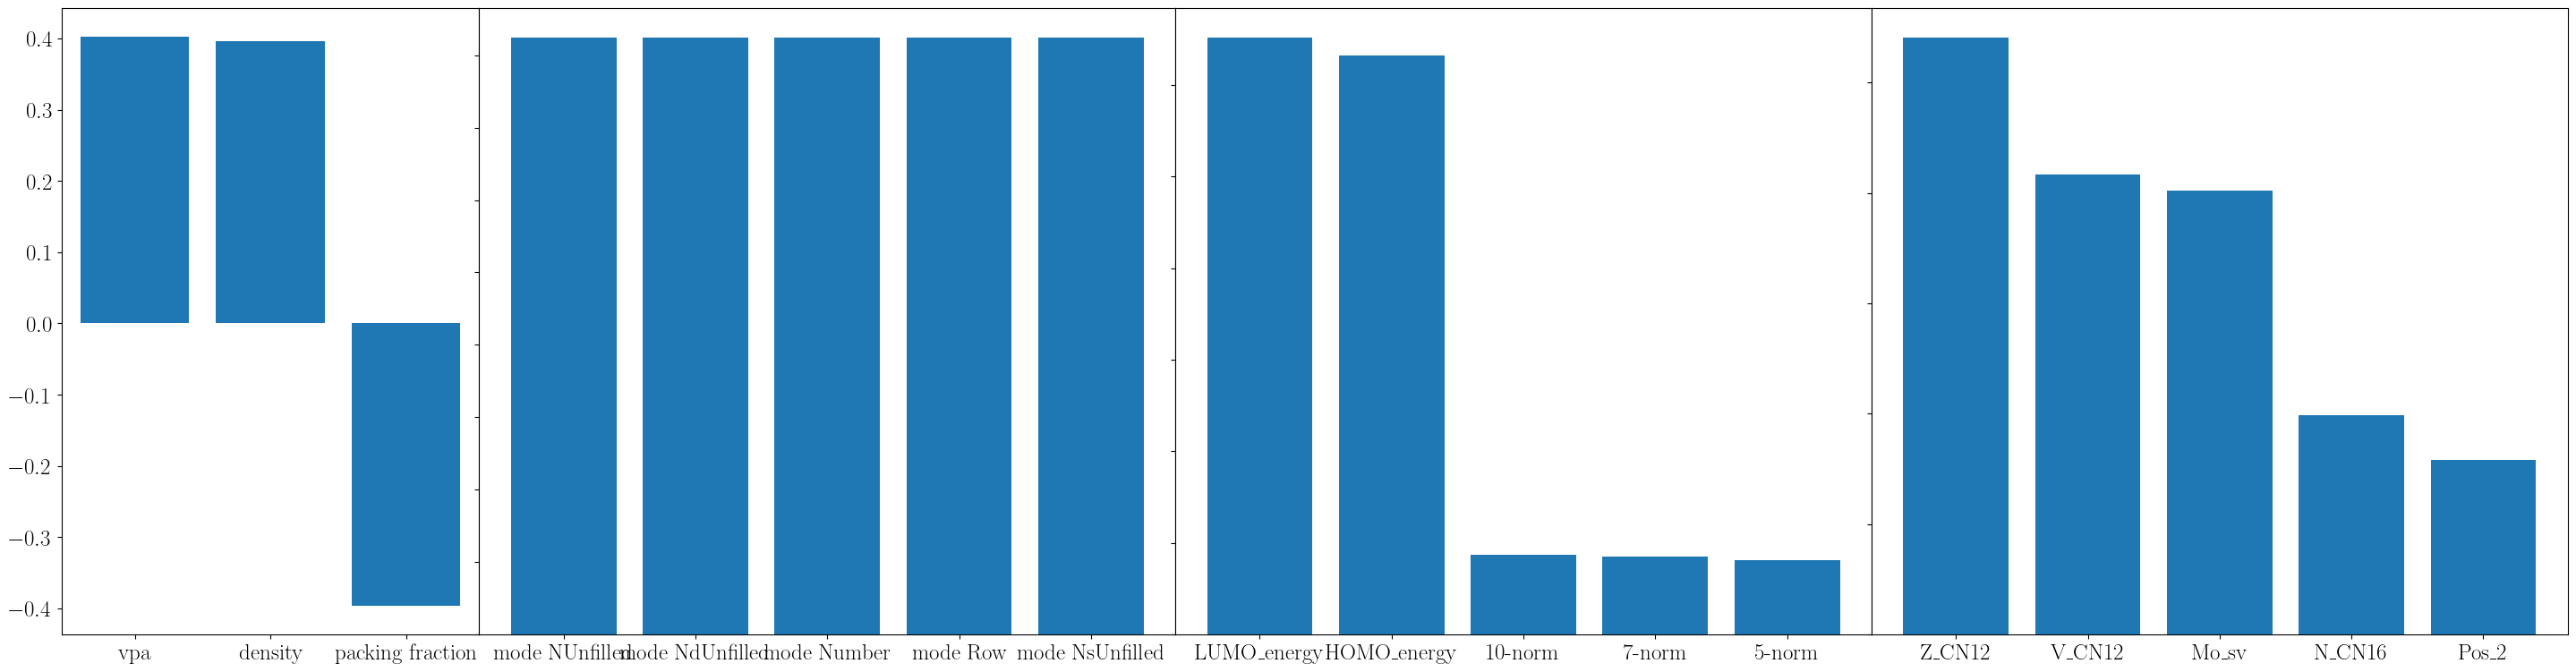

In [75]:
fig = plt.figure(figsize=(len(TargetCorrelations)*7, 10))
border=0
totalfeatures=18
for i, (group, TargetCorr) in enumerate(TargetCorrelations.items()):
    nfeatures = len(TargetCorr[:5])
    ax = fig.add_axes([border/totalfeatures,0.2,(nfeatures)/totalfeatures,0.7])
    border +=nfeatures
    ax.bar( TargetCorr[:5].index,TargetCorr[:5].values) #, ax = ax, orient='vertical')
axes = fig.get_axes()
[tax.set_yticklabels(tax.get_yticklabels(), visible=False) for tax in axes[1:]]
[tax.sharey(axes[0]) for tax in axes[:1]]
#axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90) 

# Plot correlations for most correlated

In [76]:
for name, item in DensitiFeatures.items():
    print(name)

density
vpa
packing fraction


In [77]:
DensitiFeatures[DensitiFeatures.vpa < 6]

,density,vpa,packing fraction


<Axes: xlabel='vpa', ylabel='Count'>

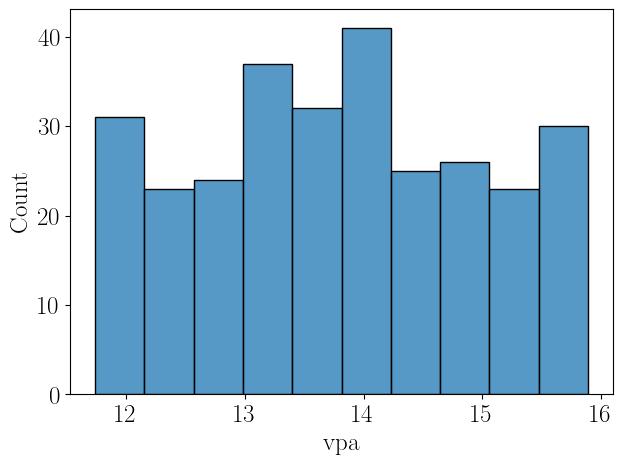

In [78]:
sns.histplot(DensitiFeatures.vpa)

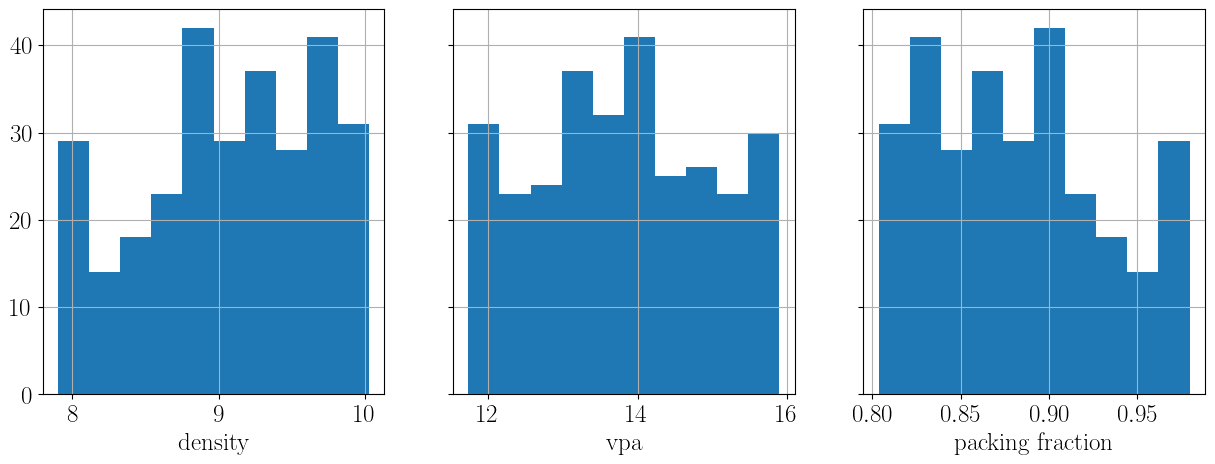

In [79]:
fig, axes = plt.subplots(1, 3, sharey = True, figsize=(15,5))
for (fname, feature), ax in zip(DensitiFeatures.items(), axes):
    feature.hist(ax=ax)
    ax.set_xlabel(fname)
#    sns.histplot(feature, ax =ax)

## By hand outlier detection:

In [80]:
selection = (FeatureGroups['density features']['packing fraction'] < 3) & (FeatureGroups['density features']['vpa']>8) &(FeatureGroups['density features']['density']<75)

In [81]:
def target_correlation_scatters(thisgroup, selection=None):
    featurenames = TargetCorrelations[thisgroup].index.to_list()
    if selection is None:
        selection = FeatureGroups[thisgroup].index
    nplots =  min([4, len(featurenames)])
    fig, axes = plt.subplots(1, nplots,  figsize=(7*4, 10), sharey=True)
    intersect = selection.intersection(BS[target_case].index)
    for ax, thisfeature in zip(axes, featurenames[:nplots]):
        ax.scatter(FeatureGroups[thisgroup][thisfeature][intersect], BS[target_case][intersect])
        ax.set_xlabel(thisfeature)
    axes[0].set_ylabel('$\Delta E_f$')

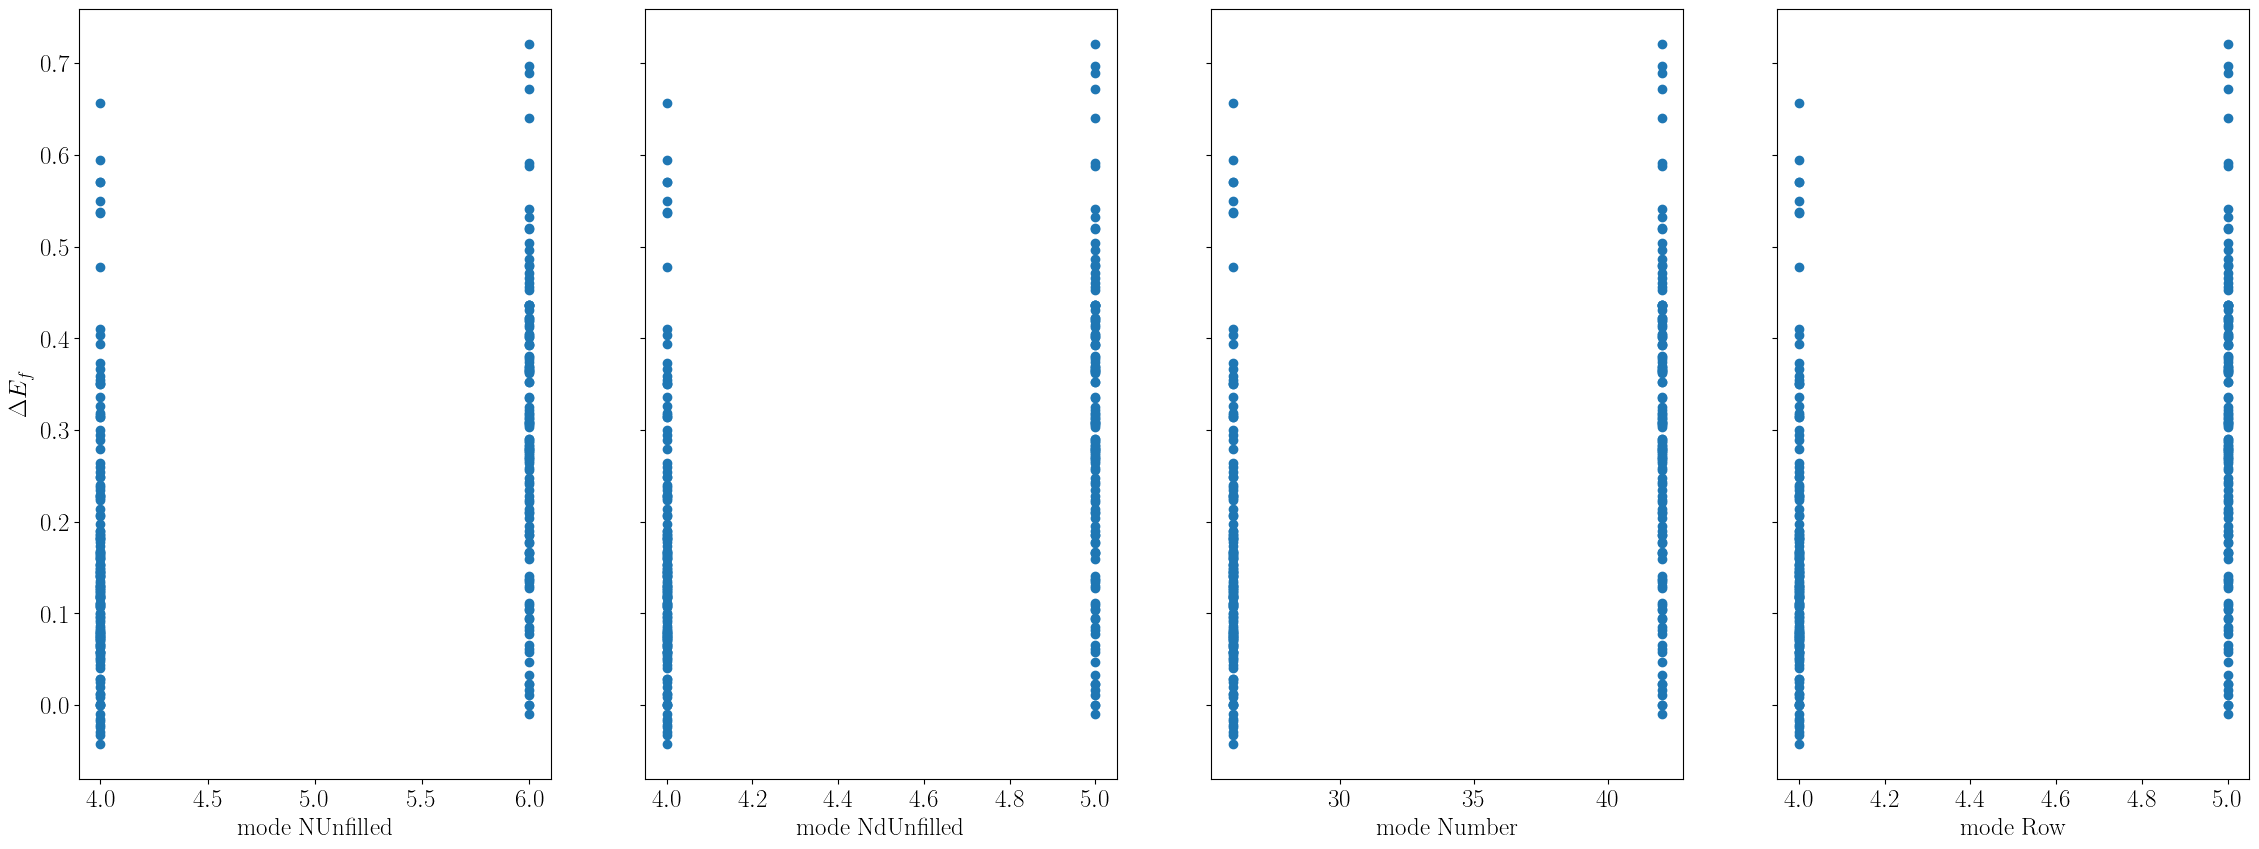

In [82]:
target_correlation_scatters('atomic features')

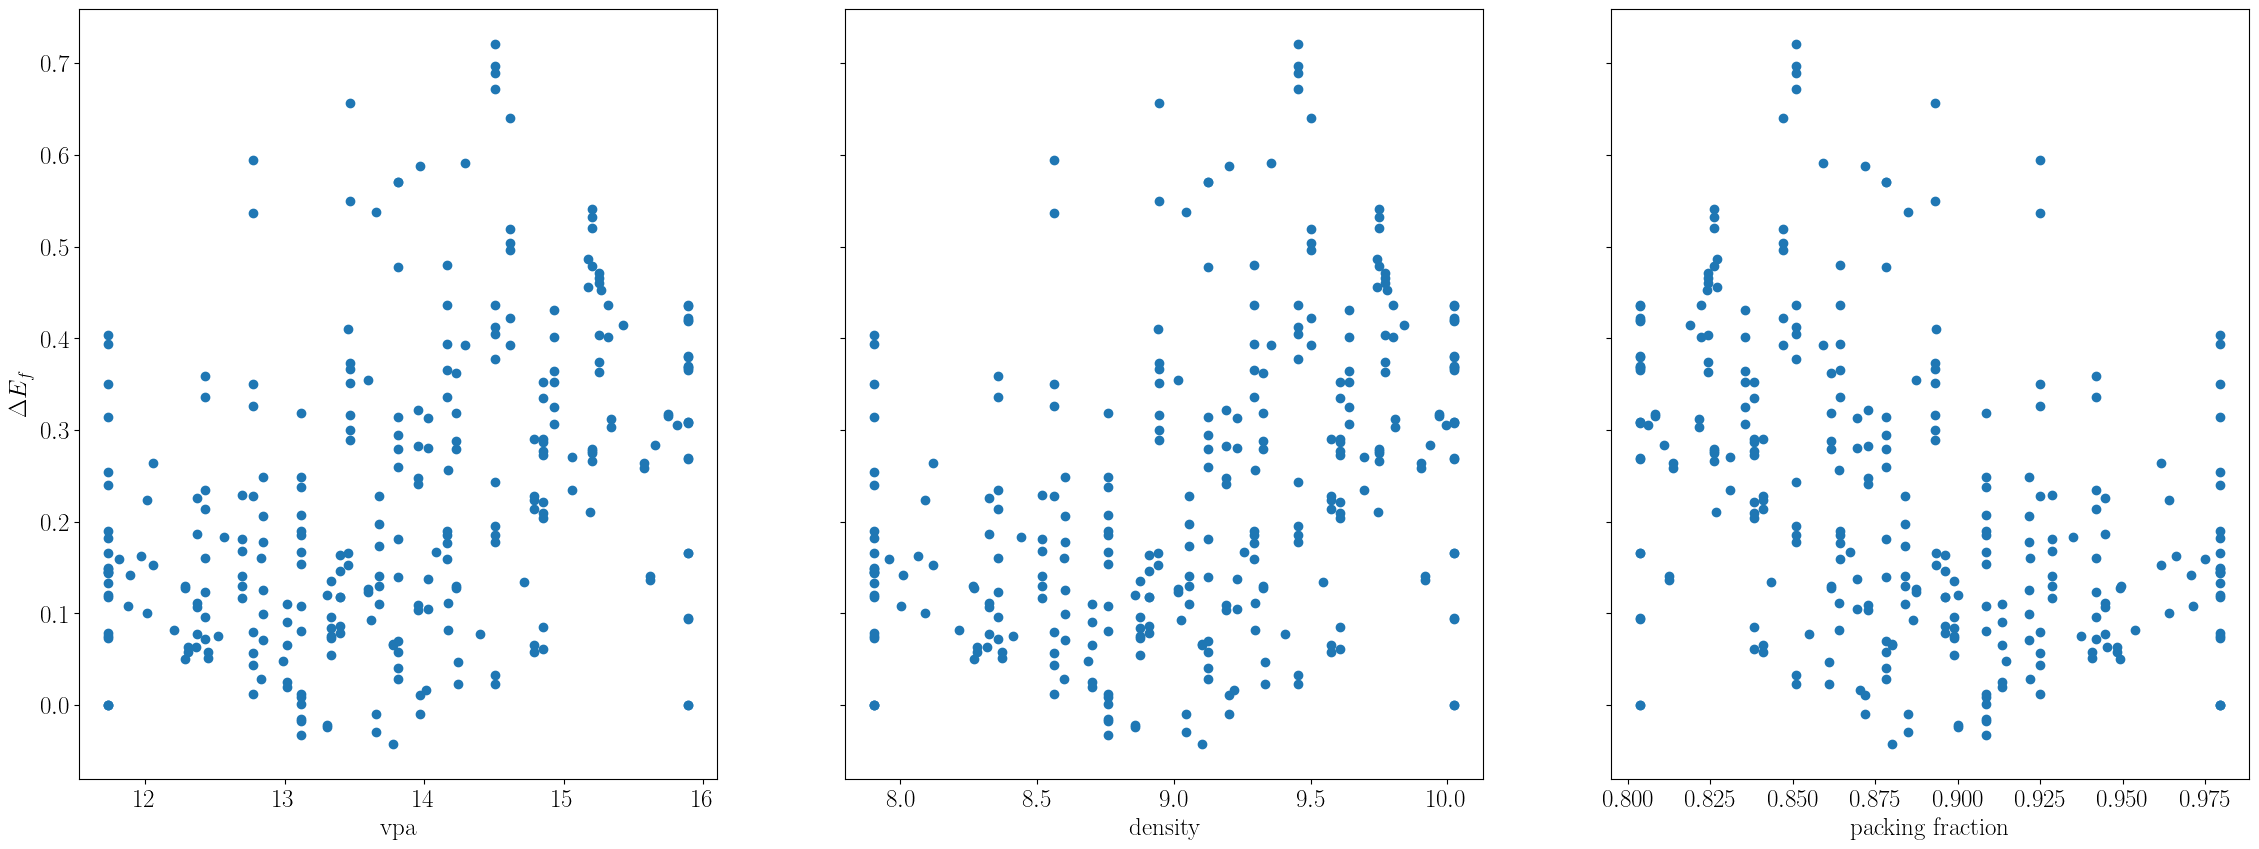

In [83]:
target_correlation_scatters('density features')#, selection=selection)

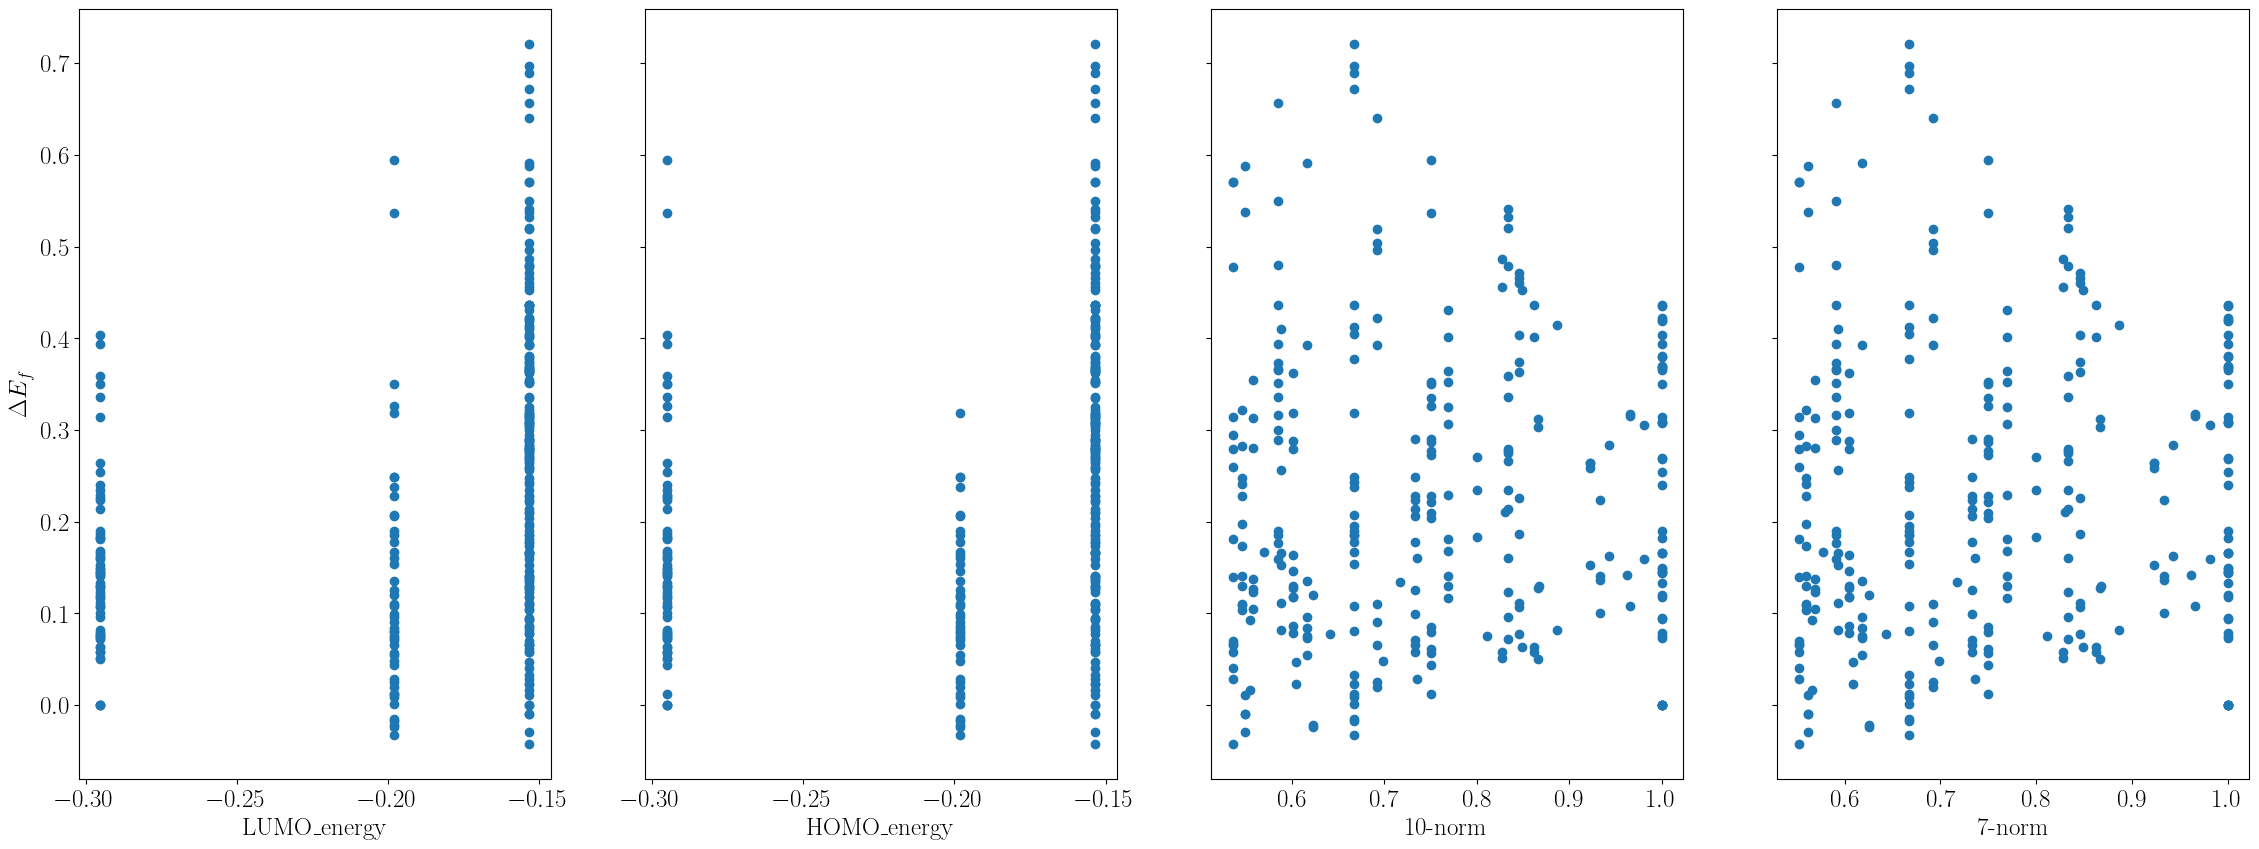

In [84]:
target_correlation_scatters('composition features')

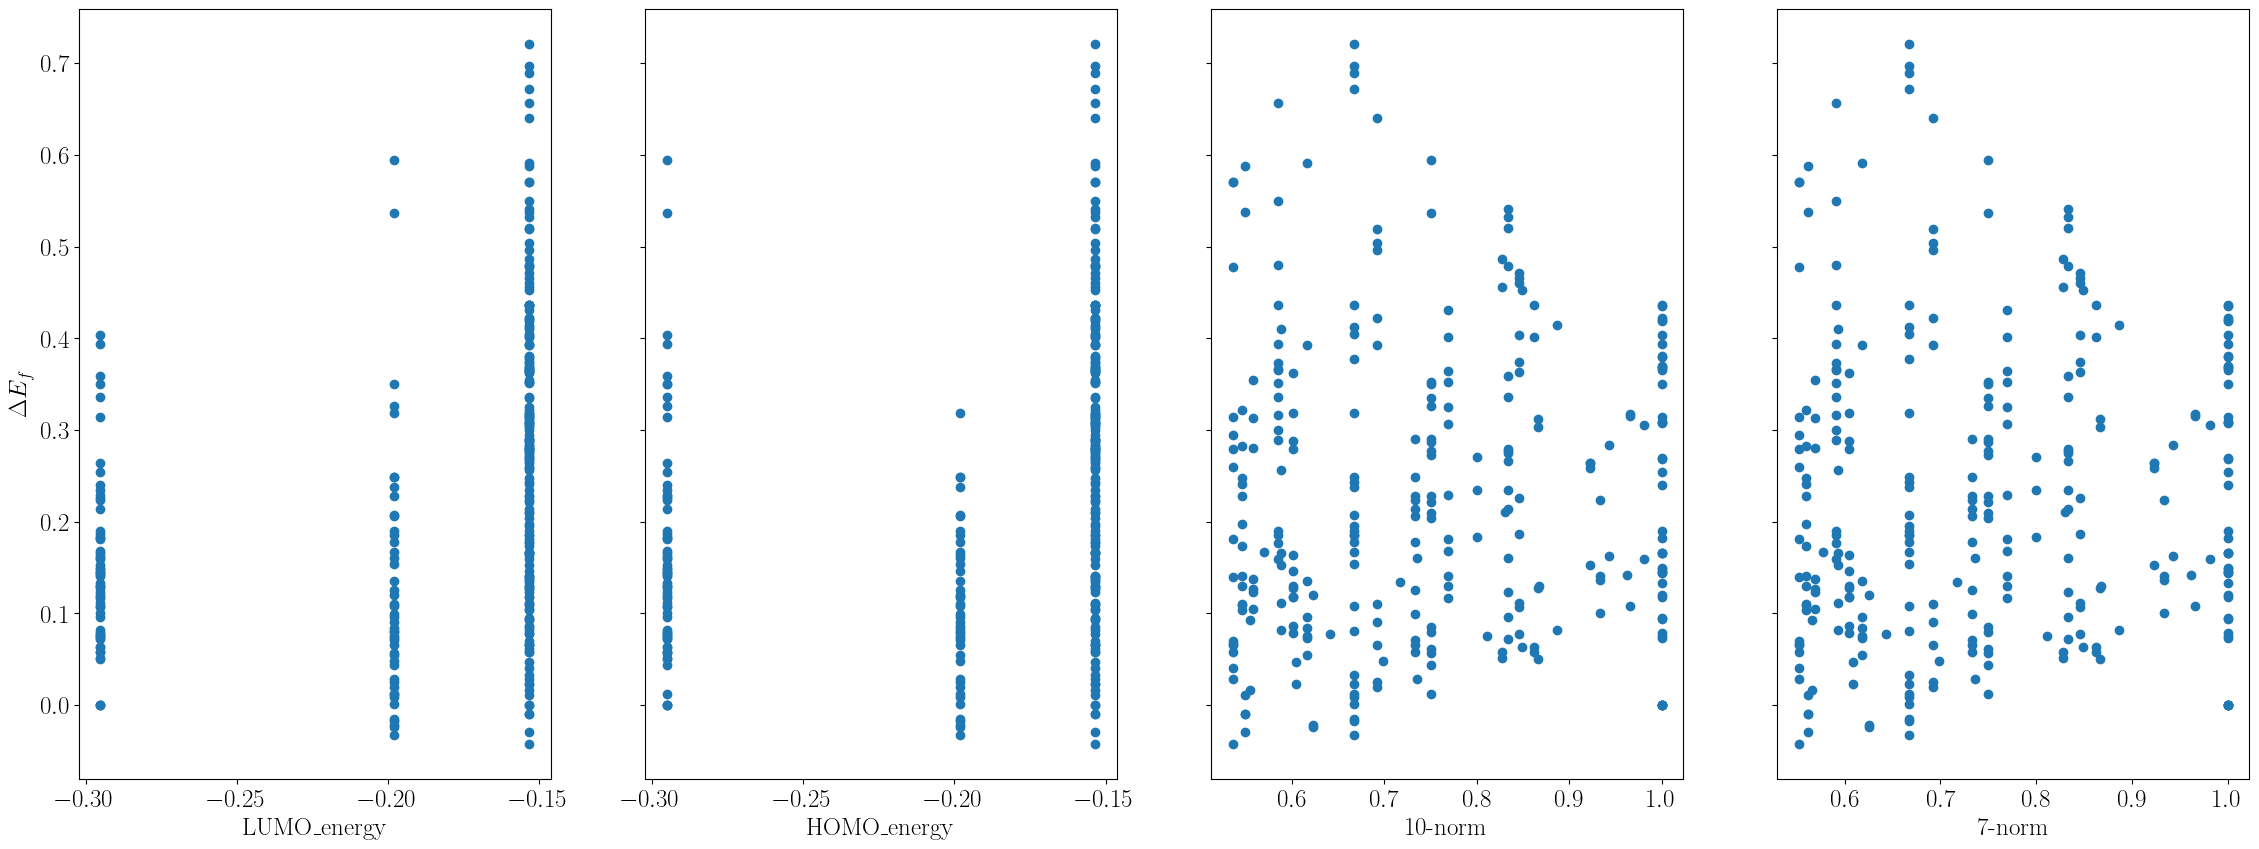

In [85]:
target_correlation_scatters('composition features')

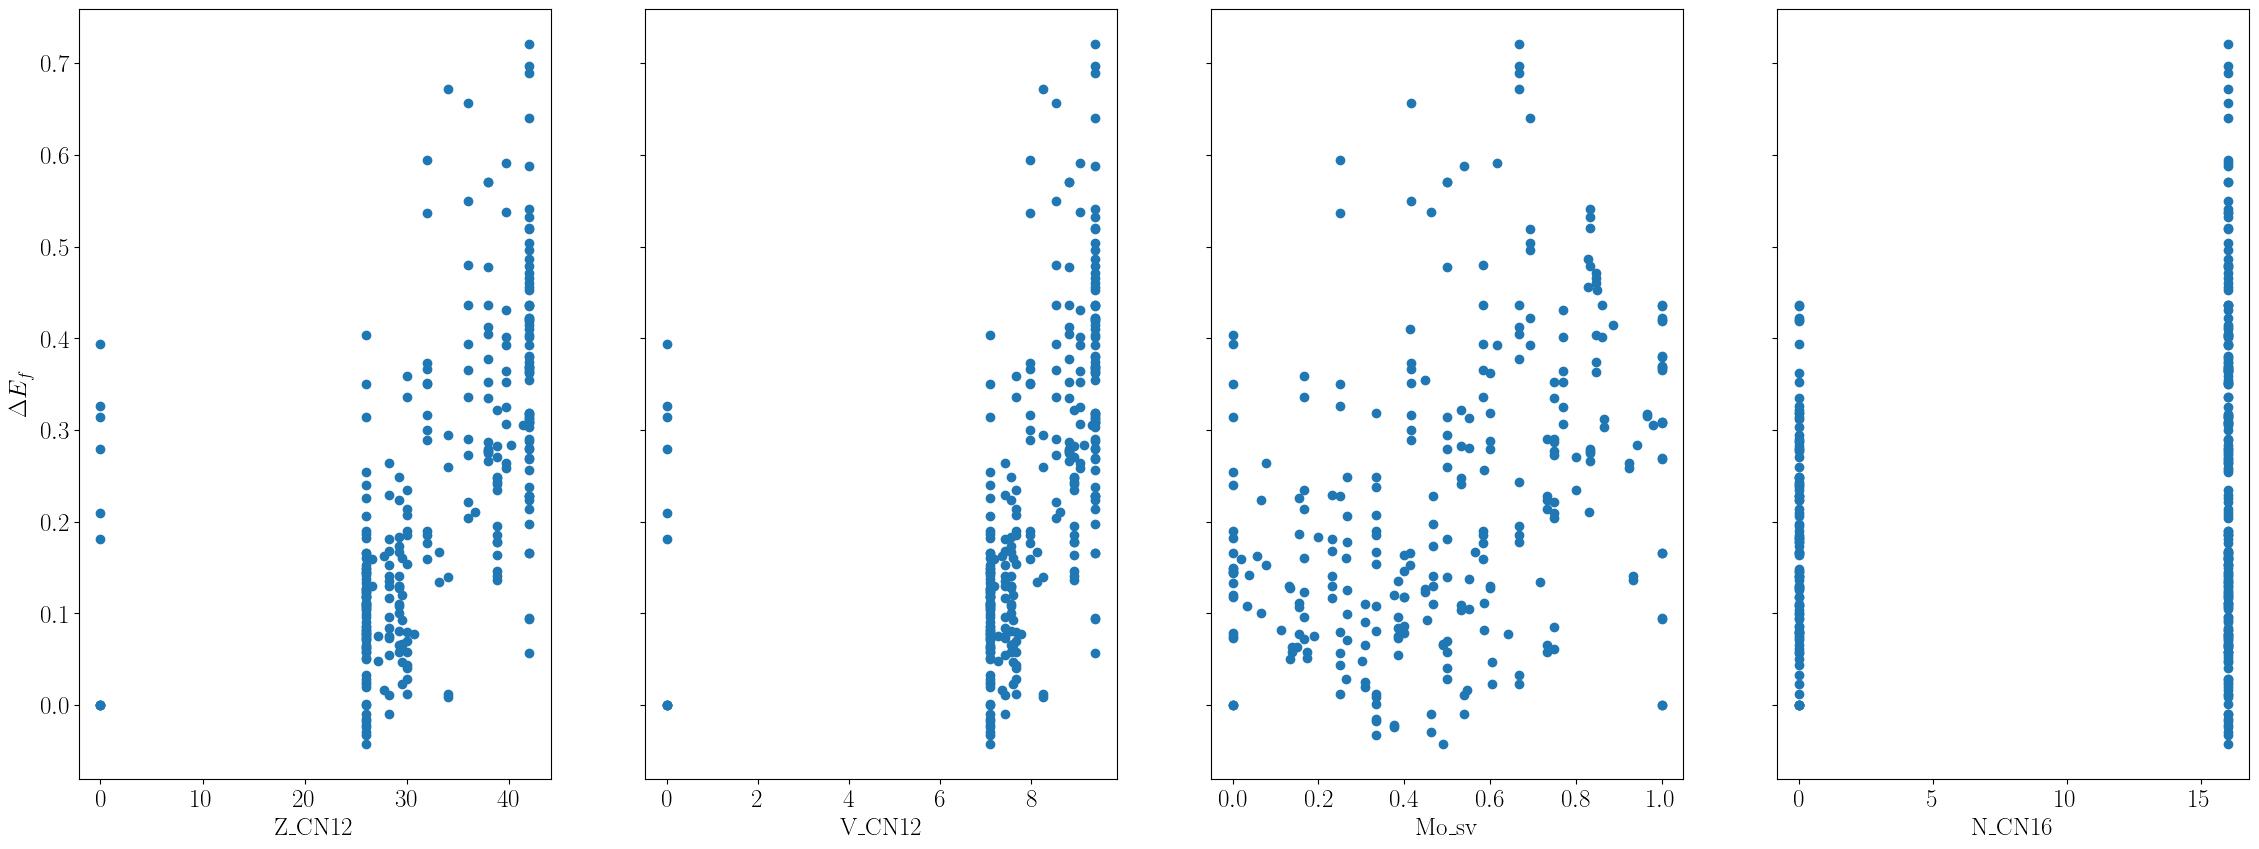

In [86]:
target_correlation_scatters('Dataset Features')

In [87]:
TargetCorrelations.keys()

dict_keys(['density features', 'atomic features', 'composition features', 'Dataset Features'])